<div style="text-align: center;">
    <h3>Bike Sharing Demand Forecasting</h3>
    <p><i>Directed & Engineered by <b>[Ammar Aladwy]</b></i></p>
    <hr style="width: 50%;">
    <p>An end-to-end Machine Learning pipeline utilizing Gradient Boosting architecture.</p>
</div>

# Bike Sharing Demand Prediction

This project analyzes the Bike Sharing Dataset and builds machine learning models to predict the number of rented bikes based on weather and time-related features.



# Dataset Description

This project uses the **Bike Sharing Dataset**, which contains hourly records of bike rentals in a bike-sharing system. The dataset includes information about weather conditions, seasonal patterns, and time-related features that may influence bike rental demand.

The goal of this project is to build a machine learning model that can predict the number of bike rentals for a given hour based on these features.


## Dataset Size
The hourly dataset contains:

- **17,379 rows** (hours)
- **17 columns**

Each row represents bike rental activity for a specific hour.

## Target Variable

**cnt**  
Total number of bikes rented during that hour.

## Important Features

- **season** = Season of the year (spring, summer, fall, winter)  
- **yr** = Year (2011 or 2012)  
- **mnth** = Month  
- **hr** = Hour of the day  
- **holiday** = Whether the day is a holiday  
- **workingday** = Whether the day is a working day  
- **weathersit** = Weather condition  
- **temp** = Normalized temperature  
- **atemp** = Feeling temperature  
- **hum** = Humidity  
- **windspeed** = Wind speed  

These features help capture both **temporal patterns** and **weather effects** that influence bike rental demand.


## Steps

**1**. Import required libraries    

**2**. Load the dataset    

**3**. Data understanding  

**4**. Exploratory Data Analysis (EDA)  

**5**. Data cleaning  



**6**. Feature selection    

**7**. Train-test split   

**8**. Feature scaling   

**9**. Model training    

**10**. Prediction   

**11**. Model evaluation   

**13**. Conclusion  
   

# **1**. Import required libraries  

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
# Load the dataset
df = pd.read_csv('/content/regression hour.csv')
df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


# **Data understanding**

In [ ]:
df.shape

(17379, 17)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [ ]:
df = df.drop('dteday',axis=1)

In [ ]:
df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


In [ ]:
df.isnull().sum()

,0
instant,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0


# **Exploratory Data Analysis (EDA)**

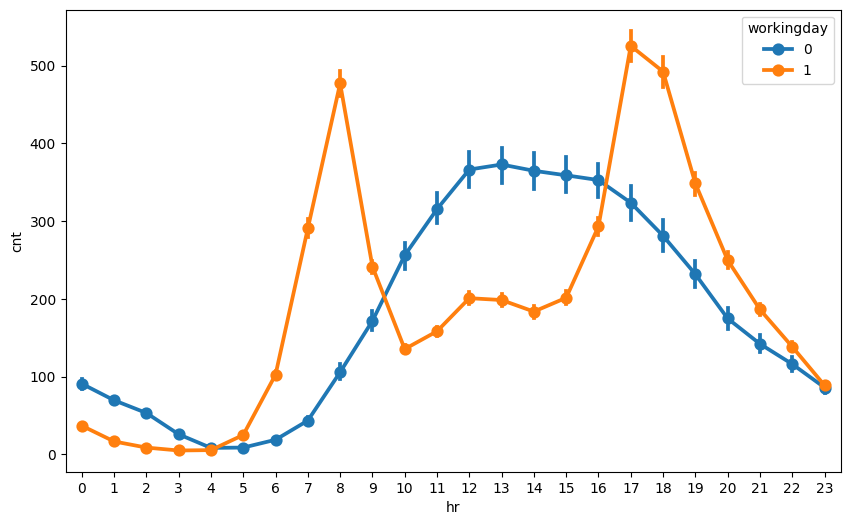

In [ ]:
plt.figure(figsize=(10,6))
sns.pointplot(data=df,x='hr',y='cnt',hue='workingday')
plt.show()

**conclusion: the variable hr combined with workingday is a crictical predictor for the model as the demand behaviour changes drastically between these two categories**

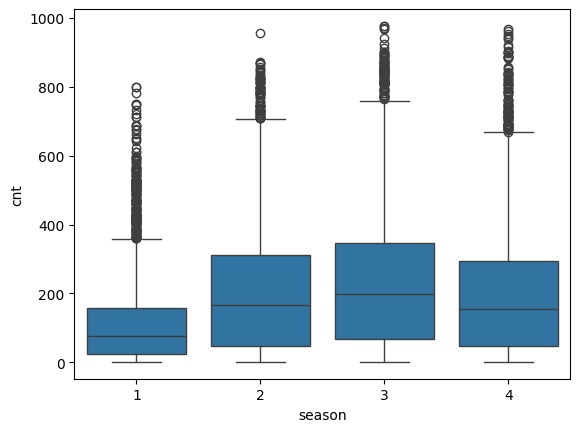

In [ ]:
sns.boxplot(data=df,x='season',y='cnt')
plt.show()

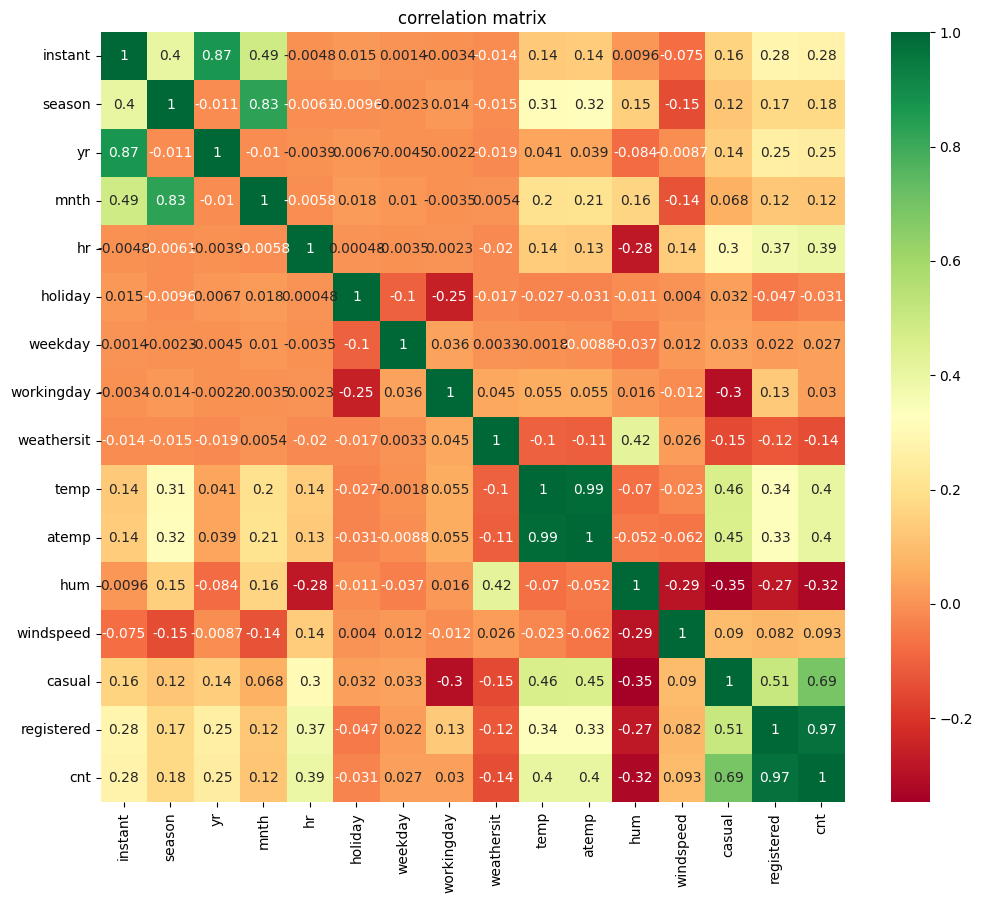

In [ ]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(),annot=True,cmap='RdYlGn')
plt.title('correlation matrix')
plt.show()

**​Insights:
Key Correlation Findings
​Positive Impact: Higher temperature (temp) and certain hours (hr) are the strongest drivers for bike rentals.
​Negative Impact: High humidity (hum) significantly reduces the demand.
​Feature Selection: atemp should be dropped because it is nearly identical to temp (Correlation = 0.99), which helps simplify the model and improve accuracy and avoid data luckage**

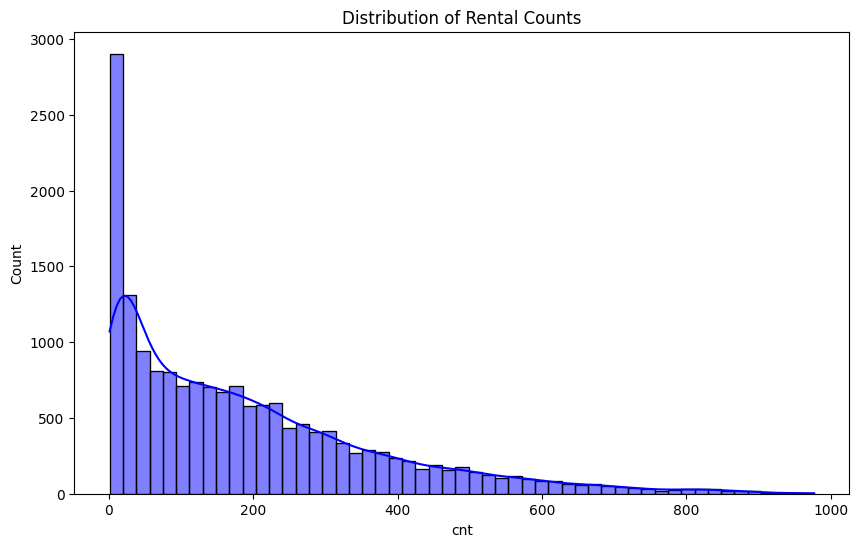

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(df['cnt'], kde=True, color='blue')
plt.title('Distribution of Rental Counts')
plt.show()

**insight: the target variable (cnt) is right-skewed so applying a log transformation will normalize the distribution and improve model accuracy**

# **Data Cleaning & Feature Selection**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   season      17379 non-null  int64  
 2   yr          17379 non-null  int64  
 3   mnth        17379 non-null  int64  
 4   hr          17379 non-null  int64  
 5   holiday     17379 non-null  int64  
 6   weekday     17379 non-null  int64  
 7   workingday  17379 non-null  int64  
 8   weathersit  17379 non-null  int64  
 9   temp        17379 non-null  float64
 10  atemp       17379 non-null  float64
 11  hum         17379 non-null  float64
 12  windspeed   17379 non-null  float64
 13  casual      17379 non-null  int64  
 14  registered  17379 non-null  int64  
 15  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12)
memory usage: 2.1 MB


In [ ]:
# (drop un neccessary columns )
cols_to_drop = ['instant','atemp','casual','registered']
df_final = df.drop(columns=cols_to_drop)
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   season      17379 non-null  int64  
 1   yr          17379 non-null  int64  
 2   mnth        17379 non-null  int64  
 3   hr          17379 non-null  int64  
 4   holiday     17379 non-null  int64  
 5   weekday     17379 non-null  int64  
 6   workingday  17379 non-null  int64  
 7   weathersit  17379 non-null  int64  
 8   temp        17379 non-null  float64
 9   hum         17379 non-null  float64
 10  windspeed   17379 non-null  float64
 11  cnt         17379 non-null  int64  
dtypes: float64(3), int64(9)
memory usage: 1.6 MB




>**​Feature Drop: Removed redundant features like atemp (to avoid multicollinearity) and ID-like columns (instant, dteday) that do not help in prediction.**





>**​Leakage Prevention: Dropped casual and registered variables because their sum is the target (cnt), which prevents data leakage**





In [ ]:
df_final['cnt'] = np.log1p(df_final['cnt'])

**Normalization: applied log transformation(log1p) to target variable cnt to fix the right-skewness and help the model acheive**

**train test split**

In [ ]:
x = df_final.drop('cnt',axis=1)
y = df_final['cnt']

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2)

# Model Training

In [ ]:
# models


from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor
DT = DecisionTreeRegressor()
RF = RandomForestRegressor()
GB = GradientBoostingRegressor()
XGB = XGBRegressor()

# Fine Tuning

In [ ]:
# 1. DecisionTreeRegressor
DT_params = {'max_depth':[10,20,30],'min_samples_leaf':[1,2,4],'criterion':['squared_error','friedman_mse']}


grid_DT = GridSearchCV(DT,DT_params,cv=5, scoring='r2', n_jobs=-1)
grid_DT.fit(x_train, y_train)
print(f"Best DT Score: {grid_DT.best_score_}")

Best DT Score: 0.9216439246332294


In [ ]:
# 2. Random Forest Params (Focus on n_estimators for better R2)
RF_params = {
    'n_estimators': [100, 300, 500],
    'max_depth': [15, 25, None],
    'min_samples_split': [2, 5, 10],
    'max_features': [1.0, 'sqrt'], # 1.0 uses all features
}
grid_RF = GridSearchCV(RF,RF_params,cv=5, scoring='r2', n_jobs=-1)
grid_RF.fit(x_train, y_train)
print(f"Best RF Score: {grid_RF.best_score_}")


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best RF Score: 0.9495311710668737


In [ ]:
# 3. Gradient Boosting Params
GB_params = {
    'n_estimators': [200, 500],
    'learning_rate': [0.05, 0.1],
    'max_depth': [4, 6],
    'subsample': [0.8, 0.9]
}
grid_GB =  GridSearchCV(GB,GB_params,cv=5, scoring='r2', n_jobs=-1)
grid_GB.fit(x_train, y_train)
print(f"Best GB Score: {grid_GB.best_score_}")

Best GB Score: 0.9584763740049818


In [ ]:
# 4. XGBoost Params (The Powerhouse for this dataset)
# Note: tree_method='hist' helps speed up training significantly in Colab
XGB_params = {
    'n_estimators': [500, 1000],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [5, 7, 9],
    'colsample_bytree': [0.8, 1.0],
    'gamma': [0, 0.1, 0.2] # To control overfitting
}
grid_XGB =  GridSearchCV(XGB,XGB_params,cv=5, scoring='r2', n_jobs=-1)
grid_XGB.fit(x_train, y_train)
print(f"Best XGB Score: {grid_XGB.best_score_}")

Best XGB Score: 0.9589220520663858


In [ ]:
DT_train = grid_DT.best_estimator_.score(x_train, y_train)
DT_test  = grid_DT.best_estimator_.score(x_test, y_test)

RF_train = grid_RF.best_estimator_.score(x_train, y_train)
RF_test  = grid_RF.best_estimator_.score(x_test, y_test)

GB_train = grid_GB.best_estimator_.score(x_train, y_train)
GB_test  = grid_GB.best_estimator_.score(x_test, y_test)

XGB_train = grid_XGB.best_estimator_.score(x_train, y_train)
XGB_test  = grid_XGB.best_estimator_.score(x_test, y_test)


print(f"{'Model':<20} | {'Train Score':<12} | {'Test Score':<12}")
print("-" * 50)
print(f"{'Decision Tree':<20} | {DT_train:.4f}       | {DT_test:.4f}")
print(f"{'Random Forest':<20} | {RF_train:.4f}       | {RF_test:.4f}")
print(f"{'Gradient Boosting':<20} | {GB_train:.4f}       | {GB_test:.4f}")
print(f"{'XGBoost':<20} | {XGB_train:.4f}       | {XGB_test:.4f}")

Model                | Train Score  | Test Score  
--------------------------------------------------
Decision Tree        | 0.9734       | 0.9263
Random Forest        | 0.9880       | 0.9514
Gradient Boosting    | 0.9813       | 0.9597
XGBoost              | 0.9823       | 0.9589


# **The best Models is**



**1 - Gradient Boosting**

**2 - XGBoost**

**3 - Random Forest**

**4 - Decision Tree**





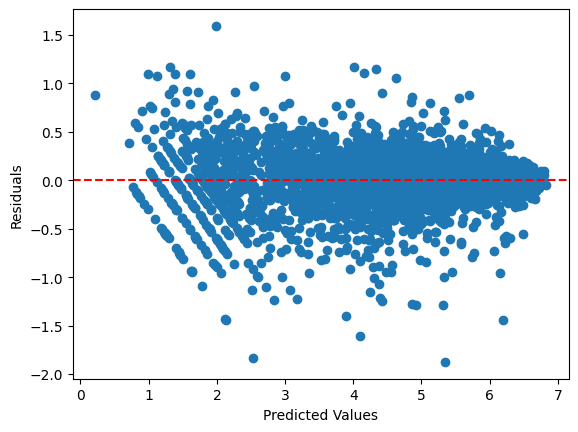

In [ ]:
y_pred = grid_GB.best_estimator_.predict(x_test)
residuals = y_test - y_pred
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.show()

​**Understanding the Residual Plot
​The residual plot displays the difference between the actual bike rental counts and our model's predicted values.
​Interpretation: * Points clustered tightly along the red horizontal line (Residuals = 0) indicate that our model is making accurate predictions with minimal error.
​The absence of any strong patterns or systematic bias confirms that our Gradient Boosting Regressor successfully captured the underlying structure of the data.
​The remaining spread represents the model's error, which is minimal, reflecting high predictive reliability.**

# Conclusion

###  Project Conclusion

This project successfully addressed the challenge of predicting bike rental demand using machine learning. Through a systematic approach, we performed data preprocessing, feature selection, and rigorous hyperparameter tuning using `GridSearchCV`.

* **Model Performance:** We compared four different regression models. The **Gradient Boosting Regressor** emerged as the top performer, achieving a robust test $R^2$ score of **0.9597**.
* **Key Findings:** The analysis confirmed that temporal features (hour, month, season) are the most significant drivers of demand.
* **Final Verdict:** The chosen model provides a highly accurate and generalized tool for demand forecasting, with minimal overfitting, making it suitable for deployment in real-world scenarios.

---